# Hydra area and body length analysis from DLC coordinates

This code analyzes Hydra body shape from DeepLabCut tracking coordinates.

Input:
A DeepLabCut `.csv` file containing 16 labeled points around the Hydra body for each frame.

What the code does:

1. Uploads a DLC `.csv` file in Google Colab.
2. Removes likelihood columns.
3. Extracts x/y coordinates for the 16 body-outline points.
4. Calculates body area using two methods:

   * polygon area from the ordered body-outline points
   * convex hull area around all tracked points
5. Calculates mouth-to-tail body length using midpoints between opposite body-outline points.
6. Plots example frames and measurement traces.
7. Saves and downloads a `.csv` file with area and length measurements.

Output:
A file named:

`original_filename_area_length.csv`

with columns:

`Frame, Area, Conv_Area, Mouth_to_Tail_Length`

Notes:
The polygon area estimates the area enclosed by the ordered body-outline points. The convex hull area estimates the smallest convex shape enclosing all points and may overestimate area when the animal is bent or concave. Mouth-to-tail length is an approximate midline length. All measurements depend on tracking quality and should be visually checked.


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.spatial import ConvexHull
from scipy.interpolate import splprep, splev
from google.colab import files

In [ ]:
# Upload the CSV file manually
uploaded = files.upload()
filename = next(iter(uploaded))

# Load the dataset, skipping the first row
df = pd.read_csv(filename, skiprows=[0])

Saving 05 e RP2 G6 Al488 1.6x0.73 0.5Hz 041824DLC_resnet50_05 e RP2 G6 Al488 area 041824Feb3shuffle1_300000.csv to 05 e RP2 G6 Al488 1.6x0.73 0.5Hz 041824DLC_resnet50_05 e RP2 G6 Al488 area 041824Feb3shuffle1_300000.csv


In [ ]:
# Drop all likelihood columns
likelihood_columns = [col for col in df.columns if col.endswith('.2') or 'likelihood' in col]
df = df.drop(columns=likelihood_columns)

# Drop the first row, which might be another header row
df = df.drop(index=0).reset_index(drop=True)

# Convert remaining x and y columns to numeric values
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [ ]:
# Function to calculate area using Shoelace formula
def calculate_polygon_area(x_coords, y_coords):
    return 0.5 * np.abs(np.dot(x_coords, np.roll(y_coords, -1)) - np.dot(y_coords, np.roll(x_coords, -1)))

# Function to calculate mouth-to-tail length
def calculate_mouth_to_tail_length(x_coords, y_coords):
    mid_x = [(x_coords[i] + x_coords[-(i+1)]) / 2 for i in range(1, 8)]
    mid_y = [(y_coords[i] + y_coords[-(i+1)]) / 2 for i in range(1, 8)]
    mid_x.insert(0, x_coords[0])  # Add mouth point
    mid_y.insert(0, y_coords[0])
    mid_x.append(x_coords[8])  # Add tail point
    mid_y.append(y_coords[8])
    return np.sum(np.sqrt(np.diff(mid_x)**2 + np.diff(mid_y)**2))

# Process data frame
total_frames = len(df)
areas, convex_hull_areas, mouth_to_tail_lengths = [], [], []

for i in range(total_frames):
    frame = df.iloc[i]
    x_coords = frame[1::2].values
    y_coords = frame[2::2].values

    areas.append(calculate_polygon_area(x_coords, y_coords))

    hull = ConvexHull(np.column_stack((x_coords, y_coords)))
    convex_hull_areas.append(hull.volume)

    mouth_to_tail_lengths.append(calculate_mouth_to_tail_length(x_coords, y_coords))

# Create DataFrame with computed values
frame_numbers = np.arange(total_frames)
areas_df = pd.DataFrame({
    'Frame': frame_numbers,
    'Area': areas,
    'Conv_Area': convex_hull_areas,
    'Mouth_to_Tail_Length': mouth_to_tail_lengths
})


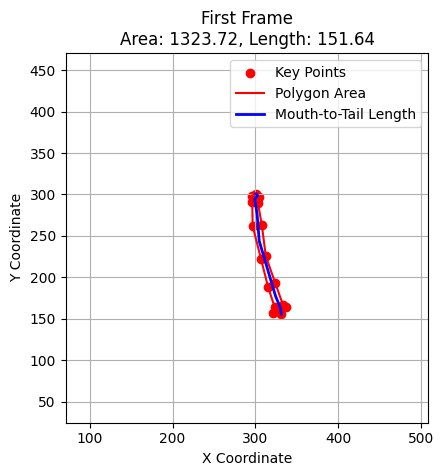

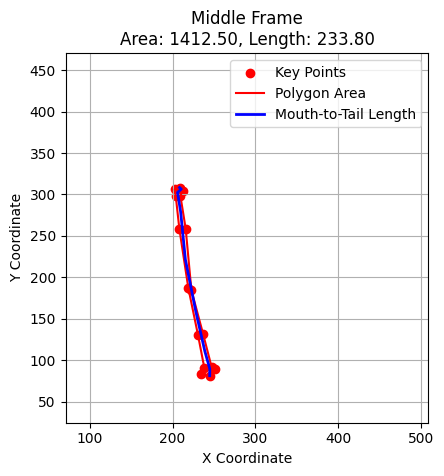

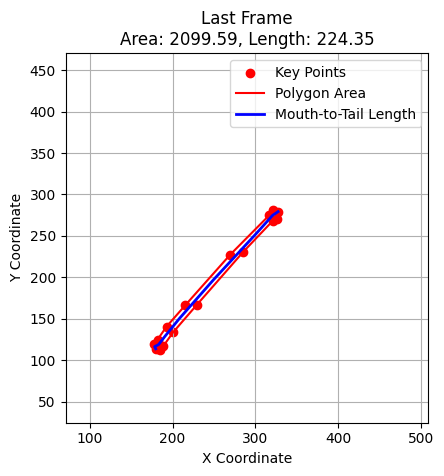

In [ ]:
def plot_frame_with_polygon_and_length(df, frame_idx, title, areas, lengths, xlim=None, ylim=None):
    fig, ax = plt.subplots()
    frame = df.iloc[frame_idx]
    x_coords = frame[1::2].values  # X coordinates of the 16 labeled points
    y_coords = frame[2::2].values  # Y coordinates of the 16 labeled points

    # Plot original points
    ax.scatter(x_coords, y_coords, color='red', label="Key Points")

    # Draw polygon connecting all points (Hydra's body shape)
    x_polygon = np.append(x_coords, x_coords[0])  # Close the shape
    y_polygon = np.append(y_coords, y_coords[0])
    ax.plot(x_polygon, y_polygon, 'r-', label="Polygon Area")

    # Compute the mouth-to-tail length line
    mid_x = [(x_coords[i] + x_coords[-(i+1)]) / 2 for i in range(1, 8)]
    mid_y = [(y_coords[i] + y_coords[-(i+1)]) / 2 for i in range(1, 8)]
    mid_x.insert(0, x_coords[0])  # Start at mouth (Point 1)
    mid_y.insert(0, y_coords[0])
    mid_x.append(x_coords[8])  # End at tail (Point 8)
    mid_y.append(y_coords[8])

    # Plot the mouth-to-tail length line
    ax.plot(mid_x, mid_y, 'b-', linewidth=2, label="Mouth-to-Tail Length")

    # Set consistent x and y limits
    if xlim and ylim:
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
    else:
        ax.set_xlim(min(x_coords) - 10, max(x_coords) + 10)
        ax.set_ylim(min(y_coords) - 10, max(y_coords) + 10)

    # Make x and y axis scales equal
    ax.set_aspect('equal', adjustable='box')

    # Adding title with area and length information
    ax.set_title(f"{title}\nArea: {areas[frame_idx]:.2f}, Length: {lengths[frame_idx]:.2f}")
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    plt.legend()
    plt.show()

# Compute global axis limits across all frames
all_x_coords = df.iloc[:, 1::2].values.flatten()
all_y_coords = df.iloc[:, 2::2].values.flatten()
xlim = (np.min(all_x_coords) - 10, np.max(all_x_coords) + 10)
ylim = (np.min(all_y_coords) - 10, np.max(all_y_coords) + 10)

# Plot first, middle, and last frame with consistent axis limits
plot_frame_with_polygon_and_length(df, 0, 'First Frame', areas, mouth_to_tail_lengths, xlim, ylim)
plot_frame_with_polygon_and_length(df, len(df) // 2, 'Middle Frame', areas, mouth_to_tail_lengths, xlim, ylim)
plot_frame_with_polygon_and_length(df, len(df) - 1, 'Last Frame', areas, mouth_to_tail_lengths, xlim, ylim)



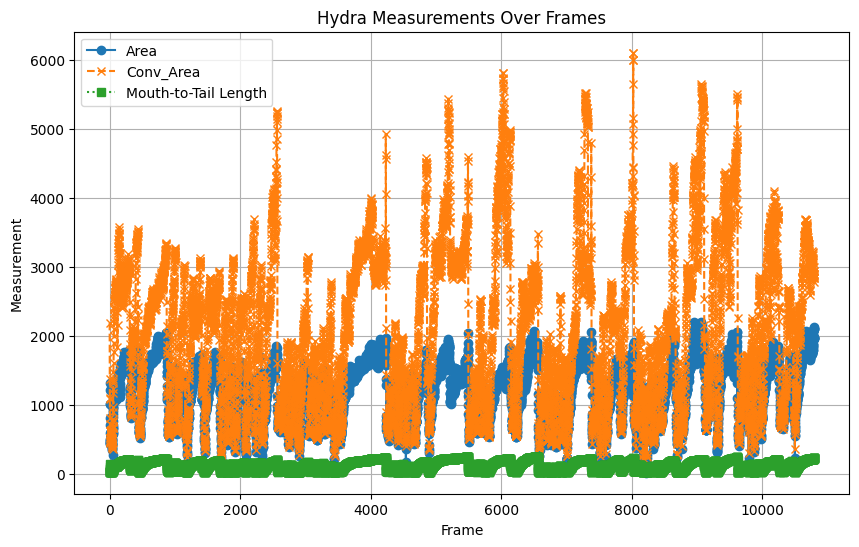

In [ ]:
# Plot results
plt.figure(figsize=(10, 6))
plt.plot(areas_df['Frame'], areas_df['Area'], label='Area', marker='o', linestyle='-')
plt.plot(areas_df['Frame'], areas_df['Conv_Area'], label='Conv_Area', marker='x', linestyle='--')
plt.plot(areas_df['Frame'], areas_df['Mouth_to_Tail_Length'], label='Mouth-to-Tail Length', marker='s', linestyle=':')
plt.xlabel('Frame')
plt.ylabel('Measurement')
plt.title('Hydra Measurements Over Frames')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Save the DataFrame to a new CSV file
new_filename = filename + '_area_length.csv'
areas_df.to_csv(new_filename, index=False)

# Download the new CSV file
files.download(new_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>